In [1]:
# imports
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, TensorDataset

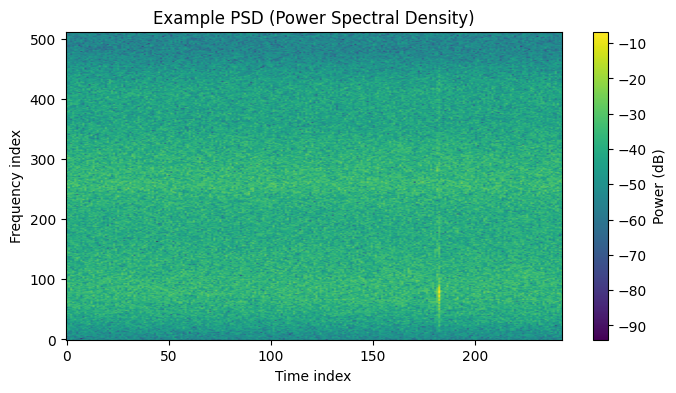

In [2]:
import matplotlib.pyplot as plt
import os

# Visualizing signal data
folder_path = "/anvil/projects/x-cis220051/corporate/aerospace-rf/fiot_highway2-main"
example_file = os.path.join(folder_path, "data/013287.npy")  # pick any file

data = np.load(example_file)

plt.figure(figsize=(8, 4))
plt.imshow(data, aspect='auto', origin='lower', cmap='viridis')
plt.title("Example PSD (Power Spectral Density)")
plt.xlabel("Time index")
plt.ylabel("Frequency index")
plt.colorbar(label="Power (dB)")
plt.show()

In [ ]:
# Load samples

folder_path = "/anvil/projects/x-cis220051/corporate/aerospace-rf/fiot_highway2-main"
train_file = os.path.join(folder_path, "train.txt")

paths, labels = [], []
with open(train_file, "r") as f:
    for line in f:
        p, lbl = line.strip().split()
        paths.append(os.path.join(folder_path, p))
        labels.append(int(lbl))

print("Loaded", len(paths), "samples")

# Load all PSD arrays into memory
arrays = [np.load(p) for p in paths]
X = np.stack(arrays)
y = np.array(labels)

print("X shape:", X.shape, "y shape:", y.shape)

Loaded 12915 samples


In [ ]:
# Converting to tensors
X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # (N,1,H,W)
y = torch.tensor(y, dtype=torch.long)

# 80/20 split
n = len(X)
n_train = int(0.8 * n)
X_train, X_val = torch.split(X, [n_train, n - n_train])
y_train, y_val = torch.split(y, [n_train, n - n_train])

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val,   y_val),   batch_size=32)

In [ ]:
# Defining the CNN
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(torch.unique(y))
print("Classes:", num_classes, "Device:", device)

model = nn.Sequential(
    nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(32 * (X.shape[2]//4) * (X.shape[3]//4), 128), nn.ReLU(),
    nn.Linear(128, num_classes)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Training loop

num_epochs = 5  # change if you want more training

for epoch in range(num_epochs):
    # ---- Training ----
    model.train()
    correct, total, train_loss = 0, 0, 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
        _, pred = out.max(1)
        total += yb.size(0)
        correct += pred.eq(yb).sum().item()

    train_acc = correct / total
    train_loss /= total

    # ---- Validation ----
    model.eval()
    val_correct, val_total, val_loss = 0, 0, 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            val_loss += loss.item() * xb.size(0)
            _, pred = out.max(1)
            val_total += yb.size(0)
            val_correct += pred.eq(yb).sum().item()

    val_acc = val_correct / val_total
    val_loss /= val_total

    print(f"Epoch {epoch+1}/{num_epochs}  "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}  "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

print("✅ Training complete!")